In [46]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv
from matplotlib import cm

In [47]:
with open('../../parent_dict_v2.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [211]:
sam = SAM()
sam.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')
gene_dict = {}
for i in range(len(sam.adata.var_names)):
    gene_dict[sam.adata.var_names[i]] = i
gene_dict['NaN'] = 'NaN'

In [212]:
org = 'DR'

In [213]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass',
       'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'ss_subclass', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn',
       'ss_subclass_nounlabeled_nmm_v4_nn_thresh30',
       'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3',
       'yanay_labels', 'yanay_label_nounlabeled', 'ss_subclass_old',
       'ss_subclass_v5_nounlabeled', 'ss_subclass_v5_nounlabeled_nn',
       'ss_subclass_nounlabeled_nmm_v5_nn',
       'ss_subclass_nounlabeled_nmm_cl_v5_nn'],
      dtype='object')

In [214]:
level = 'ss_subclass_nounlabeled_nmm_cl_v5_nn'

In [215]:
for item in sam.adata.obs[level].unique():
    if item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
    if item[:2] == 'xt':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cj':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ac':
        parent_dict[item] = 'hypo'
    if item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mo':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mg':
        parent_dict[item] = 'hypo'
        
parent_dict['hypo'] = 'hypo'
parent_dict['not hypo'] = 'not hypo'
parent_dict['NN_unknown'] = 'not hypo'

In [216]:
hl = []
for item in sam.adata.obs[level].unique():
    if parent_dict[parent_dict[item]] == 'hypo':
        hl.append(item)

In [217]:
hl

['dr_10',
 'dr_5',
 'cj_ac_xt_dr_4',
 '111 TRS-BAC Sln Glut',
 'dr_7',
 'dr_24',
 'cj_xt_dr_1',
 'ac_xt_dr_2',
 'dr_13',
 'dr_17',
 'dr_11',
 '086 MPO-ADP Lhx8 Gaba',
 'cj_ac_xt_dr_1',
 '105 TMd-DMH Foxd2 Gaba',
 'dr_16',
 'dr_6',
 'dr_3',
 'dr_12',
 '091 ARH-PVi Six6 Dopa-Gaba',
 'dr_23',
 'dr_8',
 'dr_9',
 'dr_26',
 '077 CEA-BST Gal Avp Gaba',
 'dr_14',
 'dr_22',
 'dr_32',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 'dr_34',
 'dr_29',
 '131 LHA-AHN-PVH Otp Trh Glut',
 'dr_27',
 'dr_21',
 '133 PVH-SO-PVa Otp Glut',
 '130 LHA Pmch Glut',
 'dr_35']

In [218]:
tot_neuropep = pd.read_csv('../../Neuropeptides_receptors_09132026.csv')

In [219]:
mg_neuropep = list(pd.read_csv('../../mg_np_all_09132026.csv').columns)

In [220]:
#update this to match order of NP in organism from figure 2B
neuropep = list(pd.read_csv("../../dr_np_all_09132026.csv").columns)

In [221]:
for i, val in enumerate(neuropep):
    if val not in gene_dict:
        neuropep[i] = 'nan'

In [222]:
R_set = set(tot_neuropep.columns) - set(['Neuropeptide names'])

In [223]:
receptors = set(np.unique([str(x).strip() for x in tot_neuropep[R_set].values.ravel() if pd.notna(x)]))

In [224]:
receptors = list(receptors)
neuropeptides = list(set(tot_neuropep['Neuropeptide names']))

In [225]:
len(neuropeptides)

95

In [226]:
len(receptors)

93

In [227]:
gi = [gene_dict[i] if i != 'nan' else np.nan for i in neuropep]

In [228]:
exp_array = np.zeros((len(sam.adata),len(gi))) 
tot_exp = sam.adata.X.A
for i in range(len(gi)):
    if ~np.isnan(gi[i]):
        exp_array[:,i] = tot_exp[:,gi[i]]
    else:
        exp_array[:,i] = np.nan

In [229]:
ct_array = np.zeros((len(hl), len(gi)))
ordered_names = []
for i in range(len(hl)):
    ct_array[i,:] = np.average(exp_array[sam.adata.obs[level] == hl[i]], axis = 0)
    ordered_names.append(hl[i])

In [230]:
col_min = ct_array.min(axis=0, keepdims=True)
col_max = ct_array.max(axis=0, keepdims=True)
norm_ct_array = (ct_array - col_min) / (col_max - col_min)

/scratch/miniconda/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


In [231]:
df_norm  = pd.DataFrame(norm_ct_array, index = ordered_names, columns = mg_neuropep)

In [232]:
df_norm = df_norm.sort_index()

In [233]:
df_norm.shape

(36, 148)

In [234]:
mouse_mapping = [i for i in df_norm.index if i[:3].isdigit()] 

In [235]:
mouse_mapping, len(mouse_mapping)

(['077 CEA-BST Gal Avp Gaba',
  '086 MPO-ADP Lhx8 Gaba',
  '091 ARH-PVi Six6 Dopa-Gaba',
  '092 TMv-PMv Tbx3 Hist-Gaba',
  '105 TMd-DMH Foxd2 Gaba',
  '111 TRS-BAC Sln Glut',
  '130 LHA Pmch Glut',
  '131 LHA-AHN-PVH Otp Trh Glut',
  '133 PVH-SO-PVa Otp Glut'],
 9)

In [236]:
df_norm = df_norm.loc[mouse_mapping,:]

In [237]:
reindex_np = ['Grp','Tac2','Nts','Pnoc','Gal','Agrp','Npy','Sst','Crh','Avp','Oxt','Trh','Pmch','Igf1','Pdyn'
             ,'Adcyap1','Qrfp','Npvf','Hcrt']

In [238]:
reindex_npr = ['Galr1','Calcr','Agtr1a']

In [239]:
neuropeptides = np.sort(neuropeptides)
receptors = np.sort(receptors)

In [240]:
neuropeptides

array(['Adcyap1', 'Adipoq', 'Adm', 'Adm2', 'Agrp', 'Agt', 'Apln', 'Avp',
       'Calca', 'Calcb', 'Cartpt', 'Cck', 'Cgrp', 'Chga', 'Cort', 'Crh',
       'Dbi', 'Edn1', 'Edn2', 'Edn3', 'Enho', 'Gal', 'Galp', 'Gast',
       'Gcg', 'Ghrh', 'Ghrl', 'Gip', 'Glp', 'Gnas', 'Gnrh1', 'Gnrh2',
       'Grp', 'Hcrt', 'Iapp', 'Igf1', 'Igf2', 'Igf3', 'Ins1', 'Ins2',
       'Insl3', 'Kiss1', 'Kiss2', 'Kng1', 'Lep', 'Mln', 'Nmb', 'Nms',
       'Nmu', 'Npb', 'Npff', 'Nppa', 'Nppb', 'Nppc', 'Nps', 'Npvf', 'Npw',
       'Npy', 'Nts', 'Nucb2', 'Oxt', 'Pcsk1n', 'Pdyn', 'Penk', 'Pmch',
       'Pnoc', 'Pomc', 'Ppy', 'Prl', 'Prlh', 'Prok1', 'Prok2', 'Pth2',
       'Pthlh', 'Qrfp', 'Retn', 'Retnla', 'Retnlb', 'Retnlg', 'Rln1',
       'Rln2', 'Rln3', 'Sct', 'Sst', 'Tac1', 'Tac2', 'Tac3', 'Trh', 'Ucn',
       'Ucn2', 'Ucn3', 'Uts2', 'Uts2b', 'Vgf', 'Vip'], dtype='<U7')

In [241]:
for item in neuropeptides:
    if item not in reindex_np and item in df_norm.columns:
        reindex_np.append(item)

In [242]:
for item in receptors:
    if item not in reindex_npr and item in df_norm.columns:
        reindex_npr.append(item)

In [243]:
df_norm_np = df_norm.loc[:,reindex_np]

In [244]:
df_norm_npr = df_norm.loc[:,reindex_npr]

In [245]:
len(df_norm_np.index)

9

In [246]:
len(df_norm_np.columns)

63

In [247]:
len(df_norm_npr.columns)

85

In [248]:
df_norm_np.columns

Index(['Grp', 'Tac2', 'Nts', 'Pnoc', 'Gal', 'Agrp', 'Npy', 'Sst', 'Crh', 'Avp',
       'Oxt', 'Trh', 'Pmch', 'Igf1', 'Pdyn', 'Adcyap1', 'Qrfp', 'Npvf', 'Hcrt',
       'Adipoq', 'Adm', 'Adm2', 'Agt', 'Apln', 'Calca', 'Cartpt', 'Cck',
       'Chga', 'Dbi', 'Edn1', 'Edn2', 'Edn3', 'Gcg', 'Ghrl', 'Gip', 'Gnas',
       'Gnrh1', 'Iapp', 'Igf2', 'Ins2', 'Kng1', 'Lep', 'Nmu', 'Npb', 'Npff',
       'Nppc', 'Nps', 'Npw', 'Nucb2', 'Penk', 'Pomc', 'Prl', 'Prok1', 'Prok2',
       'Pthlh', 'Rln3', 'Tac1', 'Ucn', 'Ucn3', 'Uts2', 'Uts2b', 'Vgf', 'Vip'],
      dtype='object')

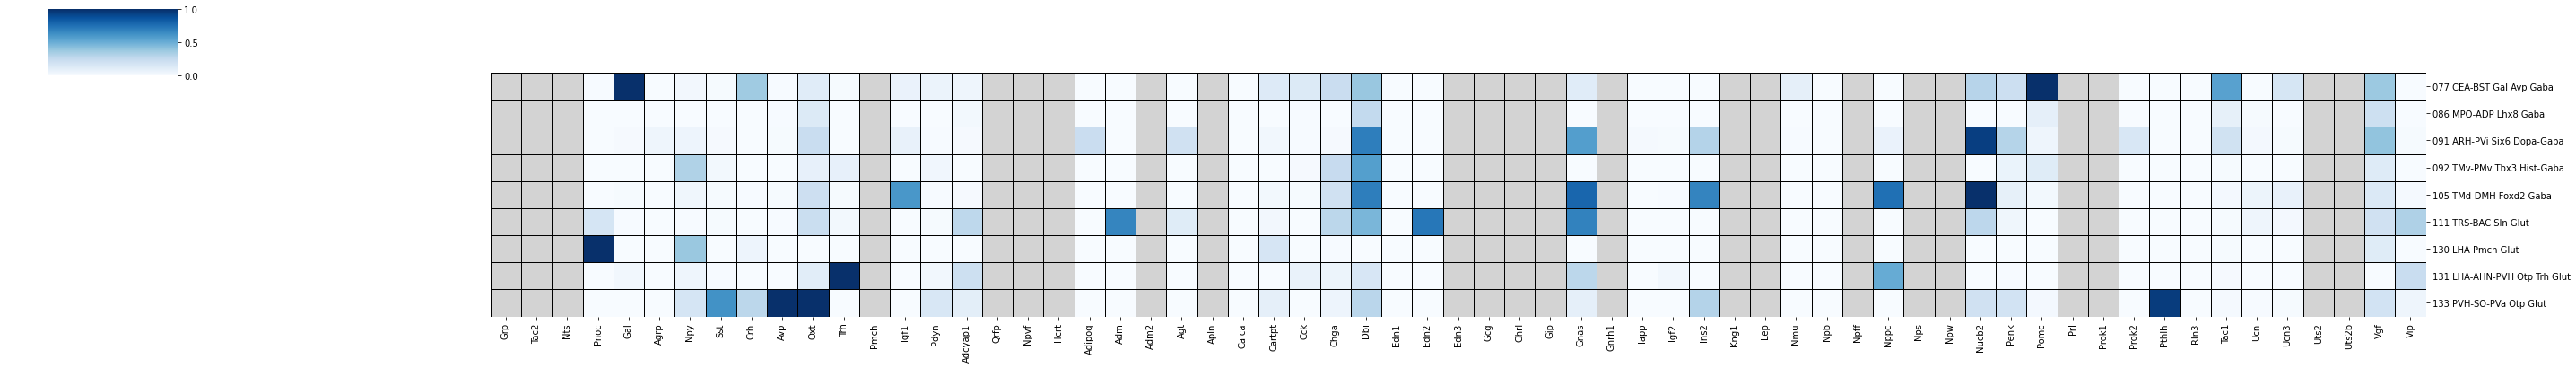

In [249]:
cmap = cm.get_cmap("Blues").copy()
cmap.set_bad(color="lightgrey") 
g = sns.clustermap(df_norm_np, cmap = cmap,linewidth=.5,linecolor = 'black', row_cluster = False, col_cluster = False,
              figsize = (40,(40*df_norm_np.shape[0])/df_norm_np.shape[1]))
plt.savefig('../../Figures/Figures_09202026/'+org+'_neuropep_mappedhypo_neurons_09132026.pdf')
plt.savefig('../../Figures/Figures_09202026/'+org+'_neuropep_mappedhypo_neurons_09132026.svg')

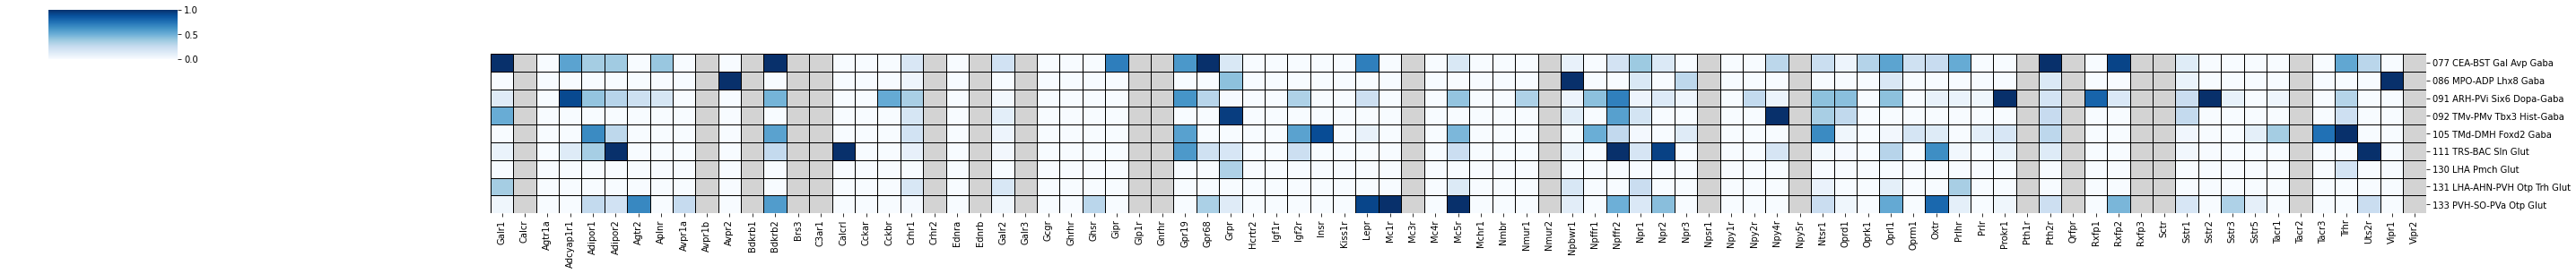

In [250]:
cmap = cm.get_cmap("Blues").copy()
cmap.set_bad(color="lightgrey") 
g = sns.clustermap(df_norm_npr, cmap = cmap,linewidth=.5,linecolor = 'black', row_cluster = False, col_cluster = False,
              figsize = (40,(40*df_norm_npr.shape[0])/df_norm_npr.shape[1]))
plt.savefig('../../Figures/Figures_09202026/'+org+'_recep_mappedhypo_neurons_09132026.pdf')
plt.savefig('../../Figures/Figures_09202026/'+org+'_recep_mappedhypo_neurons_09132026.svg')